In [1]:
import importlib
import rpa_control.models
importlib.reload(rpa_control.models)
from rpa_control.models import model_if, model_iffl
from rpa_control.strategies import run_sot_demo
from rpa_control import simulation

## Incoherent feed-forward loop (IFFL) model

/home/amir/RL/autodiff-control/src/rpa_control/simulation.py:292: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


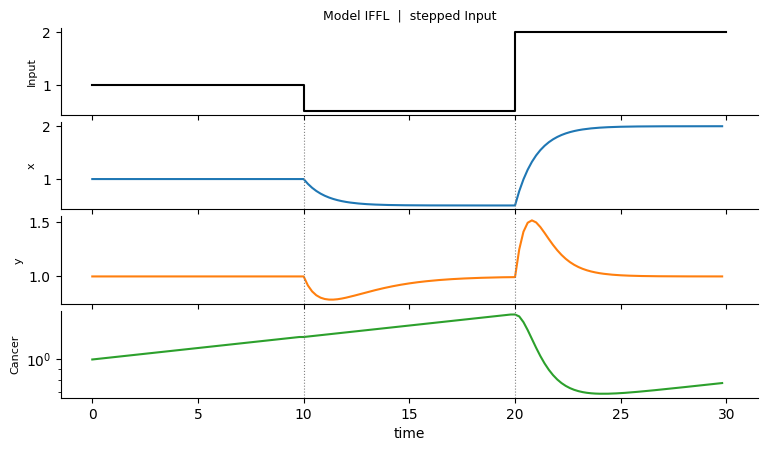

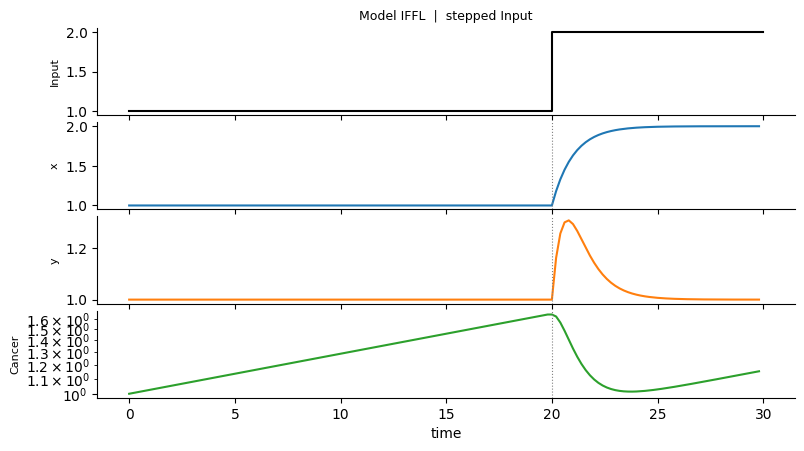

Max Output for sensitization trajectory: 1.515
Max Output for normal trajectory: 1.307
Sensitization amplified response by %: 15.89%


In [2]:
sens_input_values = [1.0, 0.5, 2.0]
sens_durations = [10.0, 10.0, 10.0]
t_sens, y_sens = simulation.stepped_trajectory(model_iffl, "Input", sens_input_values, sens_durations)

normal_input_values = [1.0, 2.0]
normal_durations = [20.0, 10.0]
t_norm, y_norm = simulation.stepped_trajectory(model_iffl, "Input", normal_input_values, normal_durations)

# comparison of the output's maximum value for the sensitization vs. normal trajectory
max_sensitization = max(y_sens[model_iffl.output_idx])
max_normal = max(y_norm[model_iffl.output_idx])

print(f"Max Output for sensitization trajectory: {max_sensitization:.3f}")
print(f"Max Output for normal trajectory: {max_normal:.3f}")
print(f"Sensitization amplified response by %: {(max_sensitization - max_normal) / max_normal * 100:.2f}%")

## Integral-feedback (IF) model

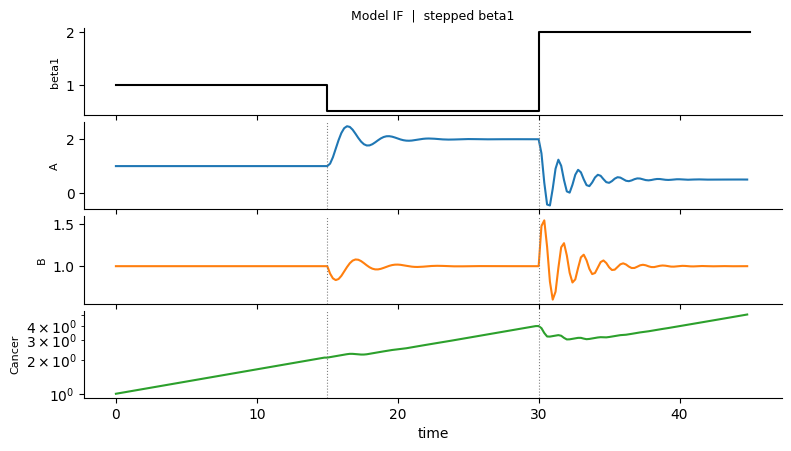

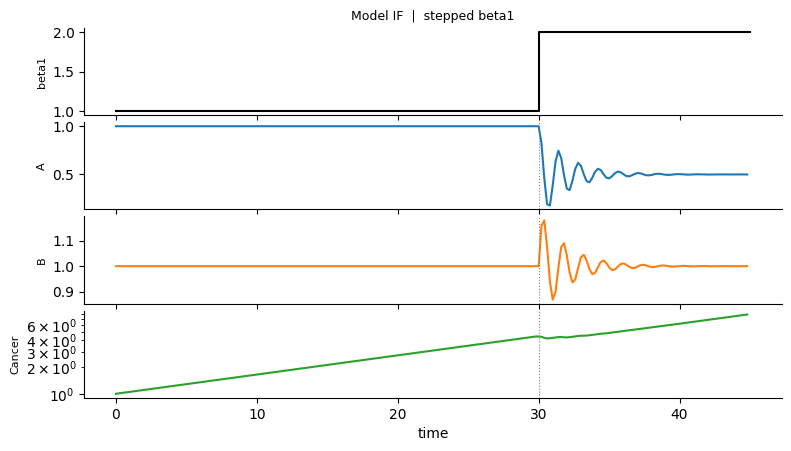

Max Output for sensitization trajectory: 1.541
Max Output for normal trajectory: 1.180
Sensitization amplified response by %: 30.54%


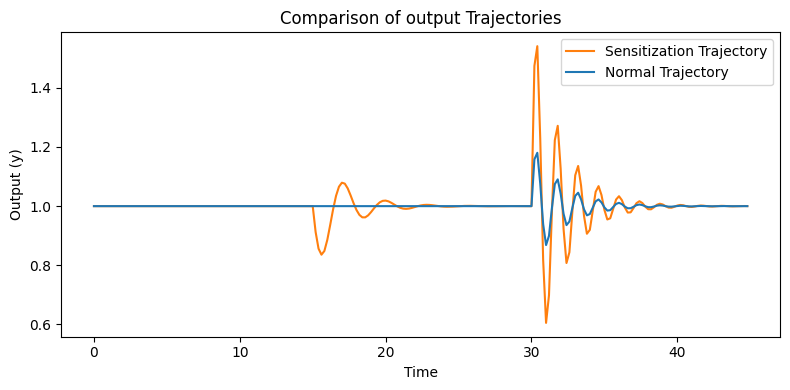

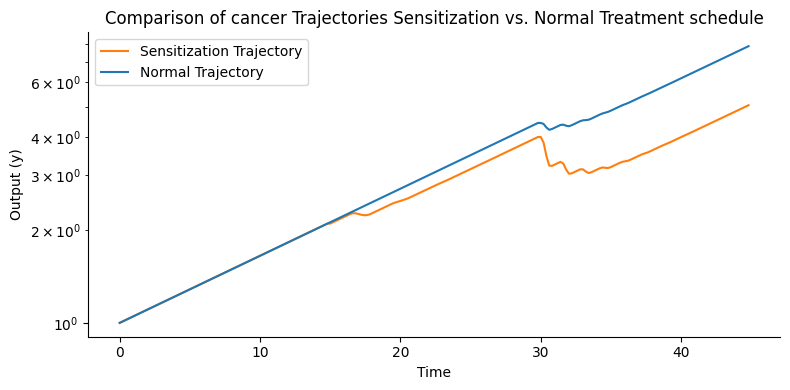

In [11]:
sens_input_values = [1.0, 0.5, 2.0]
sens_durations = [15.0] * 3
t_sens, y_sens = simulation.stepped_trajectory(model_if, "beta1", sens_input_values, sens_durations)

normal_input_values = [1.0, 2.0]
normal_durations = [30.0, 15.0]
t_norm, y_norm = simulation.stepped_trajectory(model_if, "beta1", normal_input_values, normal_durations)

# comparison of the output's maximum value for the sensitization vs. normal trajectory
max_sensitization = max(y_sens[model_if.output_idx])
max_normal = max(y_norm[model_if.output_idx])

print(f"Max Output for sensitization trajectory: {max_sensitization:.3f}")
print(f"Max Output for normal trajectory: {max_normal:.3f}")
print(f"Sensitization amplified response by %: {(max_sensitization - max_normal) / max_normal * 100:.2f}%")

# compare output trajectories on one plot
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 4))
plt.plot(t_sens, y_sens[model_if.output_idx], label='Sensitization Trajectory', color='C1')
plt.plot(t_norm, y_norm[model_if.output_idx], label='Normal Trajectory', color='C0')
plt.xlabel('Time')
plt.ylabel('Output (y)')
plt.title('Comparison of output Trajectories')
plt.legend()
plt.tight_layout()
plt.show()

# Compare cancer trajectories for sensitization vs. normal input. Cancer is the last state variable in both models.
plt.figure(figsize=(8, 4))
plt.plot(t_sens, y_sens[-1], label='Sensitization Trajectory', color='C1')
plt.plot(t_norm, y_norm[-1], label='Normal Trajectory', color='C0')
plt.xlabel('Time')
plt.ylabel('Output (y)')
ax = plt.gca()
ax.set_yscale('log')
ax.spines['right'].set_visible(False)
ax.spines['top'].set_visible(False)

plt.title('Comparison of cancer Trajectories Sensitization vs. Normal Treatment schedule')
plt.legend()
plt.tight_layout()
plt.show()

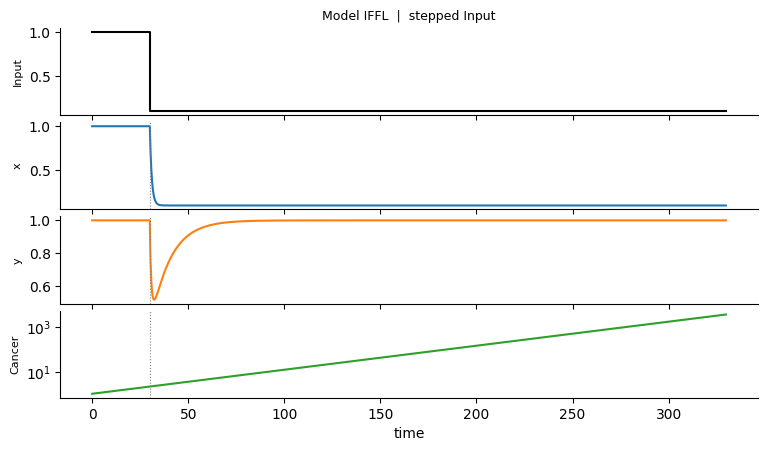

In [17]:
# test case: when u_min is close 0, does x go close to 0 and y explode? (i.e., does the system become unstable?)

normal_input_values = [1.0, 0.1]
normal_durations = [30.0, 300.0]
t_norm, y_norm = simulation.stepped_trajectory(model_iffl, "Input", normal_input_values, normal_durations)